# Predicting Conversion in Digital Marketing Campaigns
## Problem Set 1 – Binary Classification


In [51]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve
)

sns.set_style("whitegrid")


In [52]:
# Load dataset
df = pd.read_csv("data/digital_marketing_campaign_dataset.csv")

# Remove non-predictive identifier and potential leakage variable
df = df.drop(columns=["CustomerID", "ConversionRate"], errors="ignore")

# Preview dataset
df.head()


,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,69,Male,41760,Email,Retention,3898.668606,0.155725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,46,Female,88456,PPC,Awareness,1546.429596,0.277490,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,32,Female,44085,PPC,Conversion,539.525936,0.137611,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


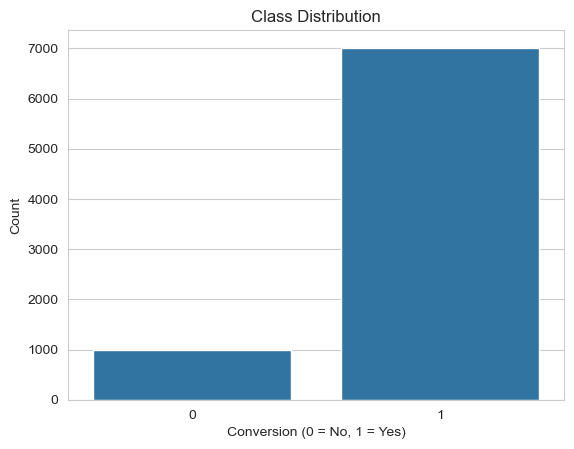

In [53]:
# Visualise class distribution to check for imbalance
sns.countplot(x=df["Conversion"])
plt.title("Class Distribution")
plt.xlabel("Conversion (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


In [54]:
# Define target variable
y = df["Conversion"]

# Define feature matrix
X = df.drop(columns=["Conversion"])


In [55]:
# Split dataset into training and test sets
# Stratification preserves class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (6400, 17)
Test set size: (1600, 17)


In [56]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

# Build preprocessing pipeline
# - Numerical features: median imputation + standard scaling
# - Categorical features: most frequent imputation + one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)


In [57]:
# Baseline model: Logistic Regression
# Chosen for interpretability and as a linear benchmark
log_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

# Fit model
log_model.fit(X_train, y_train)

# Generate predictions
log_probs = log_model.predict_proba(X_test)[:, 1]
log_preds = (log_probs >= 0.5).astype(int)

# Evaluate performance
print("LOGISTIC REGRESSION RESULTS")
print("ROC-AUC:", roc_auc_score(y_test, log_probs))
print("Precision:", precision_score(y_test, log_preds))
print("Recall:", recall_score(y_test, log_preds))
print("F1-score:", f1_score(y_test, log_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_preds))


LOGISTIC REGRESSION RESULTS
ROC-AUC: 0.7698129656046917
Precision: 0.9483870967741935
Recall: 0.7339514978601998
F1-score: 0.827503015681544
Confusion Matrix:
 [[ 142   56]
 [ 373 1029]]


In [58]:
# Random Forest model
# Chosen to capture non-linear relationships and feature interactions
rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=600,
        random_state=42,
        class_weight="balanced_subsample"
    ))
])

# Fit model
rf_model.fit(X_train, y_train)

# Generate predictions
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

# Evaluate performance
print("RANDOM FOREST RESULTS")
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1-score:", f1_score(y_test, rf_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))


RANDOM FOREST RESULTS
ROC-AUC: 0.7937362209830112
Precision: 0.8860037998733375
Recall: 0.9978601997146933
F1-score: 0.9386112042938611
Confusion Matrix:
 [[  18  180]
 [   3 1399]]


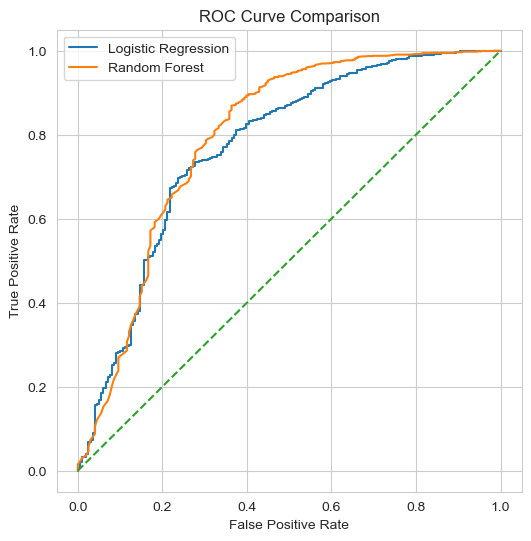

In [59]:
# Compare ROC curves of both models
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6,6))
plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


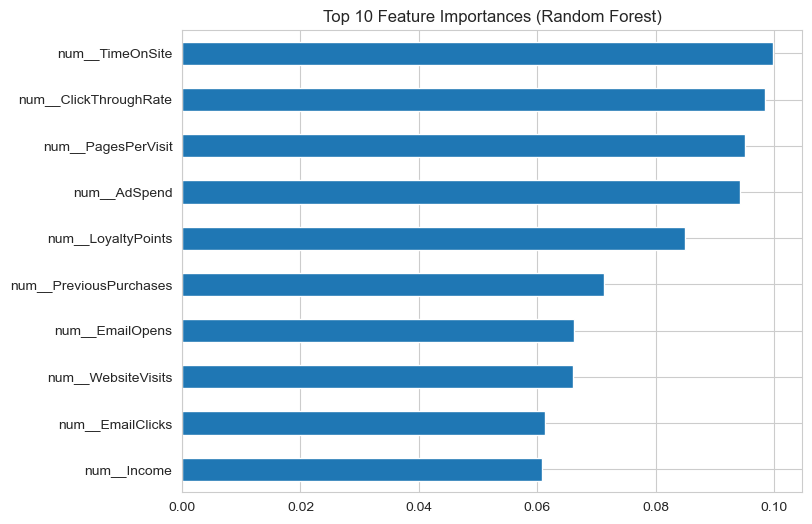

num__TimeOnSite           0.099755
num__ClickThroughRate     0.098449
num__PagesPerVisit        0.095064
num__AdSpend              0.094189
num__LoyaltyPoints        0.084915
num__PreviousPurchases    0.071266
num__EmailOpens           0.066226
num__WebsiteVisits        0.065990
num__EmailClicks          0.061295
num__Income               0.060879
dtype: float64

In [60]:
# Extract feature importances from Random Forest
importances = rf_model.named_steps["classifier"].feature_importances_
feature_names = rf_model.named_steps["preprocessing"].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

# Plot top 10 most important features
top_features = feat_imp.head(10)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

top_features
